# Instacart: from source records to trustworthy basket insights
**Member 1 · Data understanding, cleaning and unusual-value review**

**Motivation:** The team needs trustworthy product counts, basket sizes and order-timing summaries. Unchecked duplicate keys can inflate counts; filling meaningful missing values or deleting every large basket can bias results.

**The question:** How can we prepare the complete dataset without erasing real shopping behaviour?

| Story | What the audience learns |
| --- | --- |
| **Why this data?** | Orders describe customers and timing; purchase lines describe products inside baskets. |
| **What needs fixing?** | Real spacing issues in 424 product names. |
| **When should we keep a value?** | First-order gaps are missing for a reason; repeated IDs across baskets are expected. |
| **How do we investigate unusual baskets?** | Flag unusually large baskets, inspect actual rows and verify their context. |
| **What can the team trust now?** | Full-file keys, references, valid ranges and exported values are checked. |

Only the spacing-issue chart compares before and after: that change is real. Unchanged distributions appear **once**, with a clear analytical question. No rows are deleted just to make the data look cleaner. This notebook uses the complete supplied dataset, not a sample.

**Run:** Use *Run all*. Put the six original CSVs in `raw_data/`, or set the prepared ZIP path below. The files are large; allow a few GB of RAM. At the end, a ZIP contains five cleaned CSVs, audit reports, chart data and PNG figures. A Colab download button is provided.

**Provenance matters:** original mode reads the original six source files. Prepared-bundle mode rechecks the complete previously cleaned dataset and replays its logged original label strings for demonstrable examples. It prints which mode ran; it does not pass off previously cleaned files as newly discovered raw data.

Dataset: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis
Data dictionary: https://gist.github.com/jeremystan/c3b39d947d9b88b3ccff3147dbcf6c6b


In [1]:
from pathlib import Path
import csv, hashlib, json, re, shutil, unicodedata, urllib.request, zipfile, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
try:
    from IPython.display import display
except ImportError:
    if 'display' not in globals():
        def display(value):
            print(value.to_string(index=False) if isinstance(value,pd.DataFrame) else value)

pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.facecolor':'white','axes.facecolor':'white'})
RAW_DIR = Path('raw_data')
# auto uses original files when all six are present; otherwise an available prepared ZIP.
INPUT_MODE = 'auto'  # 'auto', 'original', or 'prepared'
PREPARED_ZIP = Path('Instacart_Cleaned_Data.zip')
if not PREPARED_ZIP.exists() and Path('Instacart_Cleaned_Data_Story.zip').exists():
    PREPARED_ZIP = Path('Instacart_Cleaned_Data_Story.zip')
DOWNLOAD_IF_MISSING = True
# If only original mode is available, download missing source files or add them manually.
if not RAW_DIR.exists() and Path('Instacart_Member1/data/raw').is_dir():
    RAW_DIR = Path('Instacart_Member1/data/raw')
OUT_DIR = Path('Instacart_Cleaned_Data_Story')
TABLE_DIR, AUDIT_DIR, FIG_DIR = [OUT_DIR / x for x in ['tables','audit','figures']]
for directory in [TABLE_DIR,AUDIT_DIR,FIG_DIR]:
    directory.mkdir(parents=True,exist_ok=True)
DOWNLOAD_IF_MISSING = True
CHUNK_SIZE = 500_000
START = time.monotonic()
SCHEMAS = {
 'orders.csv':['order_id','user_id','eval_set','order_number','order_dow','order_hour_of_day','days_since_prior_order'],
 'products.csv':['product_id','product_name','aisle_id','department_id'],
 'aisles.csv':['aisle_id','aisle'],
 'departments.csv':['department_id','department'],
 'order_products__prior.csv':['order_id','product_id','add_to_cart_order','reordered'],
 'order_products__train.csv':['order_id','product_id','add_to_cart_order','reordered']}
checks, inventory, field_profiles, type_changes, label_changes = [], [], [], [], []

def check(name, count, rule, scope='all rows'):
    checks.append({'check':name,'scope':scope,'issue_count':int(count),
                   'status':'PASS' if count==0 else 'REVIEW','rule':rule})

def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(4*1024*1024),b''):
            h.update(block)
    return h.hexdigest()

def canonical_label(value):
    # Clean spaces only; preserve spelling, case, punctuation, and sizes.
    return re.sub(r'\s+',' ',str(value)).strip()

def duplicates_in_entire_array(values):
    values.sort()
    return int(np.count_nonzero(values[1:]==values[:-1]))

def required_integer(series, field):
    numeric=pd.to_numeric(series,errors='coerce')
    bad=numeric.isna() | numeric.mod(1).ne(0)
    check(field+': missing, malformed, or fractional integer',bad.sum(),'Required numeric fields must be nonmissing integers.')
    if bad.any():
        raise ValueError(f'{field}: investigate {int(bad.sum())} invalid values before export.')
    return numeric

def show_figure(fig,name):
    fig.tight_layout()
    fig.savefig(FIG_DIR/name,dpi=180,bbox_inches='tight')
    plt.show()
    plt.close(fig)

BLUE, ORANGE, TEAL, GRAY = '#0072B2', '#D55E00', '#009E73', '#6B7280'
CHART_DATA = {}

def finish_axis(ax, axis='y'):
    ax.set_axisbelow(True)
    ax.grid(axis=axis, color='#DDE3EA', linewidth=.7, alpha=.75)
    ax.tick_params(length=0)
    ax.spines['left'].set_color('#A5AFBB')
    ax.spines['bottom'].set_color('#A5AFBB')

print('Requested input directory:',RAW_DIR)
print('Output directory:',OUT_DIR)
print('All applicable records will be checked; no sampling.')

Requested input directory: raw_data
Output directory: Instacart_Cleaned_Data_Story
All applicable records will be checked; no sampling.


## 1. Why do we need all six tables?

| File | One row means | Why it matters |
| --- | --- | --- |
| `orders.csv` | One customer's order | Customer, hour, sequence and previous-order gap |
| `products.csv` | One catalog product | Readable product name and category IDs |
| `aisles.csv` | One aisle | Readable category label |
| `departments.csv` | One department | Broader product category |
| `order_products__prior.csv` | One product in an earlier order | Supplied basket contents |
| `order_products__train.csv` | One product in a final training order | Additional supplied basket contents |

An `order_id` can appear on many purchase rows because a basket contains many products. The purchase key is **(order_id, product_id)**. Product lines give **neither price nor purchased quantity**.

We retain `eval_set`. It identifies **75,000 test orders whose basket contents are withheld**. They belong in Orders, but must not be treated as empty baskets.


In [2]:
# Original files are preferred. Prepared mode is a transparent replay of an audited bundle.
original_available = all((RAW_DIR/f).is_file() for f in SCHEMAS)
prepared_available = PREPARED_ZIP.is_file()
if INPUT_MODE not in {'auto','original','prepared'}:
    raise ValueError('INPUT_MODE must be auto, original or prepared.')
ACTIVE_INPUT_MODE = ('original' if original_available else 'prepared' if prepared_available else 'original') if INPUT_MODE=='auto' else INPUT_MODE
if ACTIVE_INPUT_MODE=='prepared':
    if not prepared_available:
        raise FileNotFoundError(f'Prepared ZIP not found: {PREPARED_ZIP}. Supply the ZIP or choose original mode.')
    replay_dir = OUT_DIR/'prepared_audit_replay_inputs'
    replay_dir.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(PREPARED_ZIP) as archive:
        roots = {name.split('/')[0] for name in archive.namelist() if name.endswith('/tables/orders.csv')}
        if len(roots)!=1:
            raise ValueError('The prepared ZIP must contain one tables/orders.csv root.')
        prefix = roots.pop()
        prior_manifest = pd.read_csv(archive.open(prefix+'/audit/cleaned_file_manifest.csv'))
        # Verify the complete saved table bytes against the bundle's recorded SHA-256 hashes.
        for row in prior_manifest.itertuples(index=False):
            h=hashlib.sha256()
            with archive.open(prefix+'/tables/'+row.file) as source:
                for block in iter(lambda:source.read(4*1024*1024),b''):
                    h.update(block)
            if h.hexdigest()!=row.sha256:
                raise ValueError('Prepared table hash mismatch: '+row.file)
        replay_log=pd.read_csv(archive.open(prefix+'/audit/label_change_log.csv'),keep_default_na=False)
        for filename in ['orders.csv','products.csv','aisles.csv','departments.csv']:
            frame=pd.read_csv(archive.open(prefix+'/tables/'+filename),keep_default_na=False)
            relevant=replay_log[replay_log.file.eq(filename)]
            key={'products.csv':'product_id','aisles.csv':'aisle_id','departments.csv':'department_id'}.get(filename)
            if key:
                for row in relevant.itertuples(index=False):
                    frame.loc[frame[key].eq(row.entity_id),row.column]=row.before
            frame.to_csv(replay_dir/filename,index=False)
        # Recreate prior/train membership from Orders.eval_set, preserving every purchase value.
        supplied_orders=pd.read_csv(replay_dir/'orders.csv',usecols=['order_id','eval_set'])
        lookup=np.zeros(int(supplied_orders.order_id.max())+1,dtype=np.uint8)
        lookup[supplied_orders.order_id]=supplied_orders.eval_set.map({'prior':1,'train':2,'test':3})
        with (replay_dir/'order_products__prior.csv').open('w',newline='') as prior_out, (replay_dir/'order_products__train.csv').open('w',newline='') as train_out:
            prior_out.write(','.join(SCHEMAS['order_products__prior.csv'])+'\n')
            train_out.write(','.join(SCHEMAS['order_products__train.csv'])+'\n')
            with archive.open(prefix+'/tables/order_products.csv') as source:
                for chunk in pd.read_csv(source,chunksize=CHUNK_SIZE,dtype='int64'):
                    labels=lookup[chunk.order_id.to_numpy()]
                    if not np.isin(labels,[1,2]).all():
                        raise ValueError('Prepared purchase refers to an unexpected order set.')
                    chunk.loc[labels==1].to_csv(prior_out,index=False,header=False)
                    chunk.loc[labels==2].to_csv(train_out,index=False,header=False)
        del supplied_orders,lookup,chunk,frame
    RAW_DIR=replay_dir
    INPUT_PROVENANCE='Audited prepared-bundle replay: complete cleaned tables verified; 424 logged original names restored for demonstration. Not original source byte files.'
else:
    INPUT_PROVENANCE='Original six source CSVs; complete raw-file cleaning and validation.'
print('ACTIVE MODE:',ACTIVE_INPUT_MODE)
print(INPUT_PROVENANCE)
(AUDIT_DIR/'input_provenance.txt').write_text(INPUT_PROVENANCE,encoding='utf-8')


ACTIVE MODE: prepared
Audited prepared-bundle replay: complete cleaned tables verified; 424 logged original names restored for demonstration. Not original source byte files.


In [3]:
RAW_DIR.mkdir(parents=True,exist_ok=True)
for filename in SCHEMAS:
    target=RAW_DIR/filename
    if not target.exists():
        if not DOWNLOAD_IF_MISSING:
            raise FileNotFoundError(f'Put {filename} into {RAW_DIR} or enable download.')
        url='https://www.kaggle.com/api/v1/datasets/download/psparks/instacart-market-basket-analysis/'+filename
        transfer, extracted = RAW_DIR/(filename+'.transfer.tmp'), RAW_DIR/(filename+'.extract.tmp')
        try:
            with urllib.request.urlopen(url,timeout=60) as response, transfer.open('wb') as out:
                expected=response.headers.get('Content-Length')
                shutil.copyfileobj(response,out,length=1024*1024)
            if expected and transfer.stat().st_size!=int(expected):
                raise ValueError('Transfer-size mismatch: incomplete source download.')
            if zipfile.is_zipfile(transfer):
                with zipfile.ZipFile(transfer) as archive:
                    if archive.namelist()!=[filename]:
                        raise ValueError('Unexpected archive contents.')
                    with archive.open(filename) as src, extracted.open('wb') as out:
                        shutil.copyfileobj(src,out,length=1024*1024)
            else:
                shutil.copyfile(transfer,extracted)
            extracted.replace(target)
            print('Downloaded:',filename)
        finally:
            transfer.unlink(missing_ok=True)
            extracted.unlink(missing_ok=True)
    with target.open(encoding='utf-8-sig',newline='') as f:
        header=next(csv.reader(f))
    normalized_header=[re.sub(r'\s+','_',h.strip().lower()) for h in header]
    check(filename+': header/schema mismatch',0 if normalized_header==SCHEMAS[filename] else 1,'Expected documented columns and order.',filename)
    if normalized_header!=SCHEMAS[filename]:
        raise ValueError('Inspect schema mismatch before proceeding.')
manifest=pd.DataFrame([{'file':f,'bytes':(RAW_DIR/f).stat().st_size,'sha256':sha256(RAW_DIR/f)} for f in SCHEMAS])
manifest.to_csv(AUDIT_DIR/'input_file_manifest.csv',index=False)
display(manifest[['file','bytes']])

file,bytes
orders.csv,108346970
products.csv,2166953
aisles.csv,2603
departments.csv,270
order_products__prior.csv,577550706
order_products__train.csv,24680147


In [4]:
raw = {}
KEYS = {'products.csv':['product_id'], 'aisles.csv':['aisle_id'],
        'departments.csv':['department_id'], 'orders.csv':['order_id']}
TEXT = {'product_name','aisle','department','eval_set'}
for filename in KEYS:
    frame = pd.read_csv(RAW_DIR/filename, keep_default_na=False, low_memory=False)
    raw[filename] = frame
    inventory.append({'file':filename, 'rows':len(frame), 'columns':len(frame.columns)})
    check(filename+': duplicate primary keys', frame.duplicated(KEYS[filename]).sum(), 'Entity IDs must be unique.', filename)
    check(filename+': identical duplicate records', frame.duplicated().sum(), 'Check complete identical rows.', filename)
    for col in frame:
        blank = frame[col].astype(str).str.strip().eq('') | frame[col].isna()
        field_profiles.append({'file':filename,'column':col,'missing_or_blank':int(blank.sum()),
                               'distinct_nonblank':int(frame.loc[~blank,col].nunique()),'raw_dtype':str(frame[col].dtype)})
clean = {filename:frame.copy() for filename,frame in raw.items()}
display(pd.DataFrame(inventory).rename(columns={'file':'Source table','rows':'Rows','columns':'Columns'}))
display(raw['products.csv'].head(5))
display(raw['orders.csv'][['order_id','user_id','order_number','order_hour_of_day','days_since_prior_order']].head(5))

Source table,Rows,Columns
products.csv,49688,4
aisles.csv,134,2
departments.csv,21,2
orders.csv,3421083,7


product_id,product_name,aisle_id,department_id
1,Chocolate Sandwich Cookies,61,19
2,All-Seasons Salt,104,13
3,Robust Golden Unsweetened Oolong Tea,94,7
4,Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce,38,1
5,Green Chile Anytime Sauce,5,13


order_id,user_id,order_number,order_hour_of_day,days_since_prior_order
2539329,1,1,8,
2398795,1,2,7,15.0
473747,1,3,12,21.0
2254736,1,4,7,29.0
431534,1,5,15,28.0


## Step 2 — Fix formatting: extra spaces in names

We make three simple corrections:

1. Remove spaces at the beginning or end of a name.
2. Replace an unusual **no-break space** with a normal space.
3. Replace repeated spaces with one space.

We keep the product's spelling, capital letters, size, punctuation, and ID.
The same rule is checked for aisle and department names.

**Useful later:** consistent labels make exact text searches, dropdowns,
displayed names, and comparison tables easier to use. Database joins still use
IDs. Cleaning a name does not prove two IDs refer to the same product.

In [5]:
label_changes, format_screen = [], []
for filename, field in [('products.csv','product_name'), ('aisles.csv','aisle'), ('departments.csv','department')]:
    before = raw[filename][field]
    after = (before.str.strip()
                   .str.replace(' ',' ',regex=False)
                   .str.replace(r'\s+',' ',regex=True))
    clean[filename][field] = after
    changed = before.ne(after)
    format_screen.append({'Table':filename,'Leading/trailing spaces':int(before.ne(before.str.strip()).sum()),
                          'Repeated spaces':int(before.str.contains(r'\s{2,}',regex=True).sum()),
                          'No-break spaces':int(before.str.contains(' ',regex=False).sum()),
                          'Names changed':int(changed.sum())})
    key = KEYS[filename][0]
    for i in before.index[changed]:
        label_changes.append({'file':filename,'entity_id':int(raw[filename].at[i,key]),'column':field,
                              'before':before.at[i],'before_escaped':before.at[i].encode('unicode_escape').decode('ascii'),
                              'after':after.at[i]})
    check(filename+': blank labels', after.eq('').sum(), 'Required labels must not be empty.',filename)
    check(filename+': remaining spacing issues', after.ne(after.map(canonical_label)).sum(), 'Spaces are standardized.',filename)
changes = pd.DataFrame(label_changes)
changes.to_csv(AUDIT_DIR/'label_change_log.csv',index=False)
pd.DataFrame(format_screen).to_csv(AUDIT_DIR/'text_format_screen.csv',index=False)
products, aisles, depts = clean['products.csv'], clean['aisles.csv'], clean['departments.csv']
format_before = int(raw['products.csv'].product_name.ne(products.product_name).sum())
format_after = int(products.product_name.ne(products.product_name.map(canonical_label)).sum())
assert format_after == 0, 'Review the spacing correction before proceeding.'
assert format_before == 424, 'This notebook describes the supplied complete Instacart release; review a different input.'
display(pd.DataFrame(format_screen))
print('Issue categories overlap; do not add their counts. Distinct product names changed:',format_before)

Issue categories overlap; do not add their counts. Distinct product names changed: 424


Table,Leading/trailing spaces,Repeated spaces,No-break spaces,Names changed
products.csv,4,413,16,424
aisles.csv,0,0,0,0
departments.csv,0,0,0,0


In [6]:
example_ids = [44990,7484,18]
example_reasons = ['Space at the end','Unusual no-break space','Two spaces inside the name']
examples = []
for product_id, reason in zip(example_ids,example_reasons):
    old = raw['products.csv'].set_index('product_id').at[product_id,'product_name']
    new = products.set_index('product_id').at[product_id,'product_name']
    examples.append({'Problem':reason,'Product ID':product_id,
                     'Before':old.replace(' ','[NBSP]').replace(' ','·'),
                     'After':new.replace(' ','·')})
examples = pd.DataFrame(examples)
examples.to_csv(AUDIT_DIR/'simple_format_examples.csv',index=False)
display(examples)
print('A dot (·) shows one ordinary space; [NBSP] shows an unusual no-break space.')
print('Example: Pizza for One Suprema··Frozen Pizza → Pizza for One Suprema·Frozen Pizza')

A dot (·) shows one ordinary space; [NBSP] shows an unusual no-break space.
Example: Pizza for One Suprema··Frozen Pizza → Pizza for One Suprema·Frozen Pizza


Problem,Product ID,Before,After
Space at the end,44990,Complete·Mint·Flavor·Satin·Floss[NBSP],Complete·Mint·Flavor·Satin·Floss
Unusual no-break space,7484,Southern·Butter·Pecan[NBSP]Gelato,Southern·Butter·Pecan·Gelato
Two spaces inside the name,18,Pizza·for·One·Suprema··Frozen·Pizza,Pizza·for·One·Suprema·Frozen·Pizza


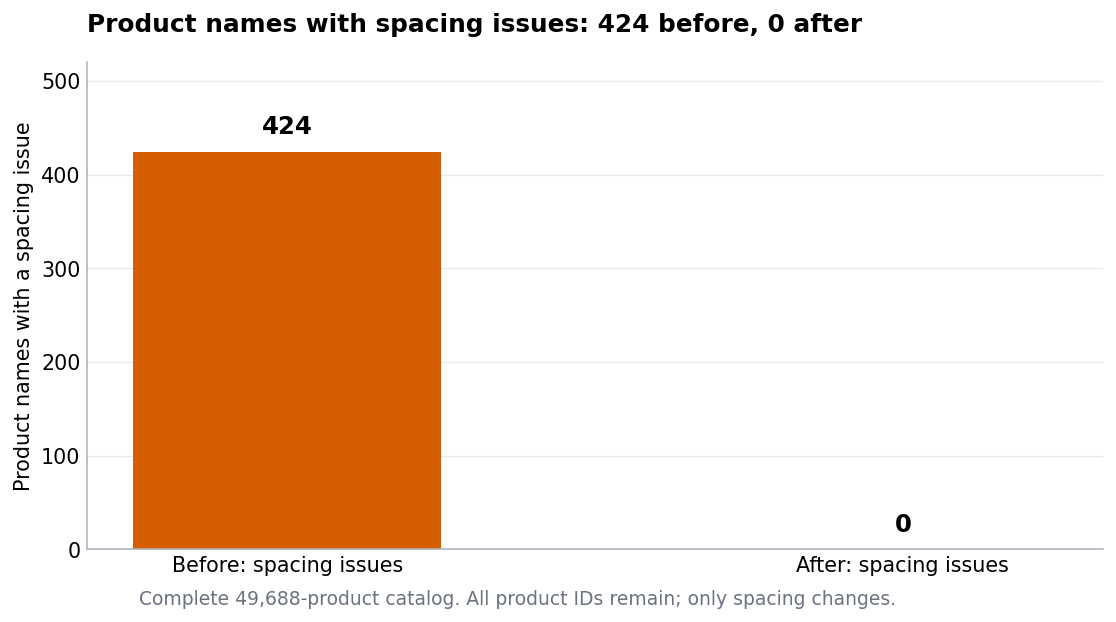

In [7]:
fig, ax = plt.subplots(figsize=(8.4,4.5))
bars = ax.bar(['Before: spacing issues','After: spacing issues'],[format_before,format_after],color=[ORANGE,TEAL],width=.5)
ax.set_title('Product names with spacing issues: 424 before, 0 after',loc='left',fontweight='bold',pad=16)
ax.set_ylabel('Product names with a spacing issue')
ax.set_ylim(0,520)
ax.yaxis.set_major_formatter(FuncFormatter(lambda n,p:f'{n:,.0f}'))
ax.bar_label(bars,labels=[f'{format_before:,}',f'{format_after:,}'],padding=7,fontsize=13,fontweight='bold')
finish_axis(ax)
fig.text(.13,-.01,'Complete 49,688-product catalog. All product IDs remain; only spacing changes.',fontsize=10,color=GRAY)
show_figure(fig,'01_spacing_issues.png')
CHART_DATA['spacing']={'labels':['Before','After'],'values':[format_before,format_after],'unit':'Product names with spacing issues','scope':f'All {len(products):,} products'}


**What changed?** Only text spacing. In product 18, `Suprema  Frozen` becomes `Suprema Frozen`. This helps exact text lookup and readable labels. Database joins still use IDs.

**What did not change?** Spelling, case, sizes, punctuation, product IDs and category membership. A name cleanup is not evidence that two product IDs should be merged.


## Step 3 — Check missing values, NULLs, and valid zeros

**Question: Why is `days_since_prior_order` blank?**

A customer's first order has no previous order. All **206,209** blanks occur
on first orders. We keep this information missing. In pandas it is a numeric
missing value (`NaN`); during MySQL import it should become **SQL NULL**.
The CSV still contains an empty field because CSV has no native NULL type.

We do not fill those blanks with zero. A **0-day gap** is a real recorded value
and means another order occurred with no whole-day gap. First-order blanks
and real zero-day gaps have different meanings.

**Useful later:** MySQL can calculate `AVG(days_since_prior_order)` from known
gaps while ignoring NULLs. Filling first-order gaps with zero would lower the
average and give a misleading answer about repeat-order timing.

In [8]:
orders = clean['orders.csv']
interval_raw = raw['orders.csv'].days_since_prior_order
interval_blank = interval_raw.astype(str).str.strip().eq('')
# Parse the day-gap column; an empty field becomes a numeric missing value.
orders['days_since_prior_order'] = pd.to_numeric(interval_raw,errors='raise')
first = orders.order_number.eq(1)
missing = orders.days_since_prior_order.isna()
check('Unexpected missing intervals',(missing & ~first).sum(),'A later order should have its previous-order gap.')
check('First orders with a previous interval',(first & ~missing).sum(),'A first order has no previous order.')
check('Intervals outside 0-30 days',(orders.days_since_prior_order.notna() & ~orders.days_since_prior_order.between(0,30)).sum(),'Allowed day gaps are 0-30.')
missing_summary = pd.DataFrame({
    'Orders':['First orders','Later orders'],
    'Before: blank fields':[int((interval_blank & first).sum()),int((interval_blank & ~first).sum())],
    'After: missing values':[int((missing & first).sum()),int((missing & ~first).sum())],
    'Action':['Keep missing; import as SQL NULL','No missing values found']})
display(missing_summary)
missing_summary.to_csv(AUDIT_DIR/'simple_missing_before_after.csv',index=False)

example_rows = list(orders.index[first][:2]) + [orders.index[orders.days_since_prior_order.eq(0)][0]] + [orders.index[orders.days_since_prior_order.eq(15)][0]]
missing_examples = []
for i in example_rows:
    value = orders.at[i,'days_since_prior_order']
    missing_examples.append({'Order ID':int(orders.at[i,'order_id']), 'Order number':int(orders.at[i,'order_number']),
                             'Before':interval_raw.at[i] if interval_raw.at[i] != '' else '[blank]',
                             'After':'Missing → SQL NULL' if pd.isna(value) else f'{value:g} days',
                             'Why':'No previous order' if pd.isna(value) else 'A valid recorded gap; retain it'})
display(pd.DataFrame(missing_examples))
pd.DataFrame(missing_examples).to_csv(AUDIT_DIR/'simple_missing_examples.csv',index=False)

profile = pd.DataFrame(field_profiles)
display(profile[['file','column','missing_or_blank']].rename(columns={'file':'Table','column':'Column','missing_or_blank':'Blank cells'}))

Orders,Before: blank fields,After: missing values,Action
First orders,206209,206209,Keep missing; import as SQL NULL
Later orders,0,0,No missing values found


Order ID,Order number,Before,After,Why
2539329,1,[blank],Missing → SQL NULL,No previous order
2168274,1,[blank],Missing → SQL NULL,No previous order
2295261,9,0.0,0 days,A valid recorded gap; retain it
2398795,2,15.0,15 days,A valid recorded gap; retain it


Table,Column,Blank cells
products.csv,product_id,0
products.csv,product_name,0
products.csv,aisle_id,0
products.csv,department_id,0
aisles.csv,aisle_id,0
aisles.csv,aisle,0
departments.csv,department_id,0
departments.csv,department,0
orders.csv,order_id,0
orders.csv,user_id,0


In [9]:
known_gaps=orders.days_since_prior_order.dropna()
zero_count=int(known_gaps.eq(0).sum())
known_mean=float(known_gaps.mean())
zero_filled_mean=float(orders.days_since_prior_order.fillna(0).mean())
null_decision=pd.DataFrame([
 {'Measure':'Correct average: known recorded gaps only','Value':f'{known_mean:.2f} days'},
 {'Measure':'If first-order blanks were filled with 0','Value':f'{zero_filled_mean:.2f} days'},
 {'Measure':'Artificial decrease from zero filling','Value':f'{known_mean-zero_filled_mean:.2f} days'},
 {'Measure':'Actual recorded zero-day gaps retained','Value':f'{zero_count:,} orders'}])
display(null_decision)
null_decision.to_csv(AUDIT_DIR/'null_zero_filling_effect.csv',index=False)
print('These are averages of recorded values, not confirmed uncapped elapsed time.')


These are averages of recorded values, not confirmed uncapped elapsed time.


Measure,Value
Correct average: known recorded gaps only,11.11 days
If first-order blanks were filled with 0,10.44 days
Artificial decrease from zero filling,0.67 days
Actual recorded zero-day gaps retained,"67,755 orders"


In [10]:
catalog = products.merge(aisles,on='aisle_id',how='left',validate='many_to_one').merge(depts,on='department_id',how='left',validate='many_to_one')
special_labels = []
for field in ['aisle','department']:
    for label in ['missing','other']:
        count = int(catalog[field].eq(label).sum())
        if count:
            special_labels.append({'Column':field,'Source category':label,'Products':count,'Decision':'Retain the supplied category label'})
display(pd.DataFrame(special_labels))
valid_values = pd.DataFrame({'Value':['0-day gap','30-day gap','Midnight: hour 0'],
                            'Rows retained':[int(orders.days_since_prior_order.eq(0).sum()),int(orders.days_since_prior_order.eq(30).sum()),int(orders.order_hour_of_day.eq(0).sum())]})
display(valid_values)
print('The word "missing" is a supplied category label, not an empty CSV cell.')
print('The maximum recorded day gap is 30. Values are retained as supplied; an exact uncapped waiting time is not inferred.')

The word "missing" is a supplied category label, not an empty CSV cell.
The maximum recorded day gap is 30. Values are retained as supplied; an exact uncapped waiting time is not inferred.


Column,Source category,Products,Decision
aisle,missing,1258,Retain the supplied category label
aisle,other,548,Retain the supplied category label
department,missing,1258,Retain the supplied category label
department,other,548,Retain the supplied category label


Value,Rows retained
0-day gap,67755
30-day gap,369323
Midnight: hour 0,22758


**Why no missing-value before/after chart?** The count stays at 206,209 because first-order gaps are correctly missing. The table and actual order examples explain the decision more clearly than two matching charts.

**Meaningful zero:** `0` records no whole-day gap between orders. **Meaningful NULL:** no previous order exists. The two meanings must remain separate.


## Step 4 — Check duplicates and values

We distinguish three cases:

| Case | What it means | What we do |
| --- | --- | --- |
| Same complete row repeated | Possible accidental duplicate | Check the full table; none were found |
| Same entity ID repeated | Conflicting record identity | Check IDs and purchase keys; none were found |
| Same cleaned name, different IDs | Two catalog entries with the same label | Keep both IDs; a name alone does not prove duplication |

There are **37 matching-name groups** after spacing cleanup. They are logged
for review and kept separate. A product can also appear in many different
orders; those are real purchases, not duplicate rows.

**Useful later:** correct duplicate checks protect purchase counts and product
rankings from accidental double counting. Keeping distinct IDs protects valid
products. MySQL keys should use IDs; do not declare `product_name` unique.

In [11]:
collisions = products[products.product_name.duplicated(keep=False)].sort_values(['product_name','product_id'])
collision_groups = int(collisions.product_name.nunique())
collisions.to_csv(AUDIT_DIR/'matching_product_names_review.csv',index=False)
example_group = collisions.product_name.iloc[0]
same_name = collisions[collisions.product_name.eq(example_group)].copy()
same_name['Before name'] = same_name.product_id.map(raw['products.csv'].set_index('product_id').product_name)
same_name['Before name'] = same_name['Before name'].str.replace(' ','·',regex=False)
display(same_name[['product_id','Before name','product_name']].rename(columns={'product_id':'Product ID','product_name':'After name'}))
print('Both product IDs remain. Matching names are not enough evidence to delete a record.')
display(pd.DataFrame({'Measure':['Product records','Repeated product IDs','Matching-name groups'],
                      'Before':[len(raw['products.csv']),int(raw['products.csv'].product_id.duplicated().sum()),int(raw['products.csv'].product_name[raw['products.csv'].product_name.duplicated(False)].nunique())],
                      'After':[len(products),int(products.product_id.duplicated().sum()),collision_groups],
                      'Decision':['Retain every product','No repeated IDs found','Retain different IDs; log matching names']}))

Both product IDs remain. Matching names are not enough evidence to delete a record.


Product ID,Before name,After name
15964,100%·Prune··Juice,100% Prune Juice
28060,100%·Prune·Juice,100% Prune Juice


Measure,Before,After,Decision
Product records,49688,49688,Retain every product
Repeated product IDs,0,0,No repeated IDs found
Matching-name groups,0,37,Retain different IDs; log matching names


### Values should make sense

Hours must be 0–23; day-of-week codes must be 0–6; a known day gap must be
0–30; reorder flags must be 0 or 1; cart positions must start at 1.
Products must refer to existing aisles and departments. Purchases must refer
to existing orders and products.

**Useful later:** valid hours make the order-time chart reliable, and valid
references allow joins without silently losing purchases. Large basket sizes
are retained when their records are valid; a large number alone is not an error.

The two next cells perform the full checks. Their implementation can stay
collapsed during your presentation; the results below are the material to explain.

In [12]:
for filename,key in [('products.csv','product_id'),('aisles.csv','aisle_id'),('departments.csv','department_id'),('orders.csv','order_id'),('orders.csv','user_id')]:
    check(filename+'.'+key+': nonpositive IDs',(clean[filename][key]<=0).sum(),'Identifiers are positive.')
check('Invalid order numbers',(orders.order_number<1).sum(),'Sequence starts at 1.')
check('Invalid day-of-week codes',(~orders.order_dow.between(0,6)).sum(),'Codes are 0-6; weekday-name mapping is not assumed.')
check('Invalid hour codes',(~orders.order_hour_of_day.between(0,23)).sum(),'Hour is 0-23.')
check('Duplicate user/order-number pairs',orders.duplicated(['user_id','order_number']).sum(),'Sequence number is unique within each user.')
sequence=orders.groupby('user_id',observed=True).order_number.agg(['size','min','max'])
check('Users with missing/noncontiguous sequence numbers',((sequence['min']!=1)|(sequence['size']!=sequence['max'])).sum(),'With unique positive numbers, size=max and min=1 establish contiguous histories.')
user_max=orders.groupby('user_id',observed=True).order_number.transform('max')
is_final=orders.eval_set.isin(['train','test'])
check('Train/test orders outside final position',(is_final & orders.order_number.ne(user_max)).sum(),'Final release label occurs at the end of each user history.')
final_counts=orders.loc[is_final].groupby('user_id',observed=True).size().reindex(sequence.index,fill_value=0)
check('Users without exactly one final labelled order',(final_counts!=1).sum(),'Every supplied user has one train/test final order.')
check('Products with missing aisle references',(~products.aisle_id.isin(aisles.aisle_id)).sum(),'Every product aisle exists.')
check('Products with missing department references',(~products.department_id.isin(depts.department_id)).sum(),'Every product department exists.')
mapping=products[['aisle_id','department_id']].drop_duplicates().sort_values('aisle_id')
check('Aisles assigned multiple departments',(products.groupby('aisle_id').department_id.nunique()!=1).sum(),'Observed aisle_id -> department_id.')
check('Aisles missing from mapping',(~aisles.aisle_id.isin(mapping.aisle_id)).sum(),'All aisles have a verified department mapping.')
map_with_names=aisles.merge(mapping,on='aisle_id',validate='one_to_one')
map_with_names.to_csv(AUDIT_DIR/'aisle_department_mapping.csv',index=False)
reconstructed=products.drop(columns='department_id').merge(mapping,on='aisle_id',validate='many_to_one')[products.columns]
equal=reconstructed.sort_values('product_id').reset_index(drop=True).equals(products.sort_values('product_id').reset_index(drop=True))
check('Catalog reconstruction mismatches',0 if equal else 1,'Proposed decomposition must preserve every cleaned product field and row.')

print('Catalog IDs and references checked. Aisle-to-department mapping saved for Member 2.')

Catalog IDs and references checked. Aisle-to-department mapping saved for Member 2.


In [13]:
max_order,max_product=int(orders.order_id.max()),int(products.product_id.max())
product_base=max_product+1
max_sequence=int(orders.order_number.max())+1
order_exists=np.zeros(max_order+1,bool); product_exists=np.zeros(max_product+1,bool)
order_ids=orders.order_id.to_numpy(dtype=np.int64)
order_exists[order_ids]=True; product_exists[products.product_id.to_numpy(dtype=np.int64)]=True
eval_lookup=np.zeros(max_order+1,np.uint8)
eval_lookup[order_ids]=orders.eval_set.astype(str).map({'prior':1,'train':2,'test':3}).to_numpy(dtype=np.uint8)
user_lookup=np.zeros(max_order+1,np.uint32); sequence_lookup=np.zeros(max_order+1,np.uint16)
user_lookup[order_ids]=orders.user_id.to_numpy(dtype=np.uint32)
sequence_lookup[order_ids]=orders.order_number.to_numpy(dtype=np.uint16)
basket_counts=np.zeros(max_order+1,np.int32); max_cart=np.zeros(max_order+1,np.uint16)
observed_products=np.zeros(max_product+1,bool)
all_pair_keys,all_history_keys=[],[]
source_counts={}
for filename,expected_set in [('order_products__prior.csv',1),('order_products__train.csv',2)]:
    pair_chunks,complete_chunks,position_chunks,history_chunks=[],[],[],[]
    file_orders=np.zeros(max_order+1,bool); file_products=np.zeros(max_product+1,bool)
    rows=orphan_orders=orphan_products=wrong_set=bad_flags=bad_cart=0
    min_values={c:float('inf') for c in SCHEMAS[filename]}; max_values={c:float('-inf') for c in SCHEMAS[filename]}
    cart_values,reorder_values=set(),set()
    for chunk in pd.read_csv(RAW_DIR/filename,chunksize=CHUNK_SIZE,keep_default_na=False):
        for col in chunk.columns:
            # Stop on malformed values; never coerce missing required keys into zero.
            v=pd.to_numeric(chunk[col],errors='coerce')
            if v.isna().any() or v.mod(1).ne(0).any():
                raise ValueError(f'Inspect invalid required values in {filename}.{col}')
            chunk[col]=v
            min_values[col]=min(min_values[col],int(v.min())); max_values[col]=max(max_values[col],int(v.max()))
        oid=chunk.order_id.to_numpy(dtype=np.int64); pid=chunk.product_id.to_numpy(dtype=np.int64)
        cart=chunk.add_to_cart_order.to_numpy(dtype=np.int64); flag=chunk.reordered.to_numpy(dtype=np.int64)
        valid_o=(oid>0)&(oid<=max_order); valid_p=(pid>0)&(pid<=max_product)
        exists_o=np.zeros(len(chunk),bool); exists_p=np.zeros(len(chunk),bool)
        exists_o[valid_o]=order_exists[oid[valid_o]]; exists_p[valid_p]=product_exists[pid[valid_p]]
        orphan_orders+=int((~exists_o).sum()); orphan_products+=int((~exists_p).sum())
        wrong_set+=int((eval_lookup[oid[exists_o]]!=expected_set).sum())
        bad_flags+=int((~np.isin(flag,[0,1])).sum()); bad_cart+=int(((cart<1)|(cart>=32768)).sum())
        if not exists_o.all() or not exists_p.all() or bad_flags or bad_cart:
            raise ValueError('Invalid references/flags/positions require review before exact-key encoding and export.')
        pair=oid*product_base+pid
        pair_chunks.append(pair)
        # Fixed positional base is valid after bounds checks; these encodings are exact, not hashes.
        complete_chunks.append((pair*32768+cart)*2+flag)
        position_chunks.append(oid*32768+cart)
        history_chunks.append((user_lookup[oid].astype(np.int64)*product_base+pid)*max_sequence*2+sequence_lookup[oid].astype(np.int64)*2+flag)
        file_orders[oid]=True; file_products[pid]=True
        basket_counts+=np.bincount(oid,minlength=max_order+1).astype(np.int32)
        np.maximum.at(max_cart,oid,cart.astype(np.uint16))
        cart_values.update(np.unique(cart).tolist()); reorder_values.update(np.unique(flag).tolist())
        rows+=len(chunk)
        if rows%5_000_000==0:
            print(f'{filename}: {rows:,} rows parsed')
    pairs=np.concatenate(pair_chunks); complete=np.concatenate(complete_chunks); positions=np.concatenate(position_chunks)
    history=np.concatenate(history_chunks)
    del pair_chunks,complete_chunks,position_chunks,history_chunks
    pair_dups=duplicates_in_entire_array(pairs)
    row_dups=duplicates_in_entire_array(complete)
    position_dups=duplicates_in_entire_array(positions)
    del complete,positions
    for label,count,rule in [
      ('missing order references',orphan_orders,'All order references exist.'),
      ('missing product references',orphan_products,'All product references exist.'),
      ('wrong evaluation labels',wrong_set,'File membership matches Orders.eval_set.'),
      ('invalid reorder flags',bad_flags,'Flag is 0 or 1.'),
      ('invalid cart positions',bad_cart,'Cart positions are positive integers within encoding bounds.'),
      ('duplicate primary-key pairs',pair_dups,'Check complete file, not only chunks.'),
      ('identical duplicate records',row_dups,'Check all four fields jointly.'),
      ('duplicate cart positions',position_dups,'One position per order.'),
      ('labelled orders without supplied baskets',int(((eval_lookup==expected_set)&~file_orders).sum()),'Every prior/train order has its supplied basket.')]:
        check(filename+': '+label,count,rule,filename)
    for col in SCHEMAS[filename]:
        distinct=int(file_orders.sum()) if col=='order_id' else int(file_products.sum()) if col=='product_id' else len(cart_values) if col=='add_to_cart_order' else len(reorder_values)
        field_profiles.append({'file':filename,'column':col,'missing_or_blank':0,'distinct_nonblank':distinct,'raw_dtype':'validated integer'})
    source_counts[filename]=rows
    inventory.append({'file':filename,'rows':rows,'columns':4})
    all_pair_keys.append(pairs); all_history_keys.append(history)
    observed_products|=file_products
    print(f'{filename}: {rows:,} rows checked; duplicate pairs={pair_dups:,}')
combined_pairs=np.concatenate(all_pair_keys); combined_history=np.concatenate(all_history_keys)
del all_pair_keys,all_history_keys
union_duplicates=duplicates_in_entire_array(combined_pairs)
check('Prior/train union duplicate purchase keys',union_duplicates,'Combined link-table key must stay unique.')
del combined_pairs
combined_history.sort()
history_group=combined_history//(max_sequence*2)
first_occurrence=np.empty(len(history_group),bool)
first_occurrence[0]=True; first_occurrence[1:]=history_group[1:]!=history_group[:-1]
reorder_mismatches=int(np.count_nonzero((combined_history%2).astype(bool)!=~first_occurrence))
check('Reordered flags disagreeing with complete user-product history',reorder_mismatches,'First occurrence is 0; later occurrences are 1.')
del combined_history,history_group,first_occurrence
observed_baskets=basket_counts>0
check('Noncontiguous cart positions',np.count_nonzero(observed_baskets&(basket_counts!=max_cart)),'Positive unique positions must cover 1 to basket line count.')
check('Test orders with supplied baskets',np.count_nonzero((eval_lookup==3)&observed_baskets),'Test basket contents are withheld in this release.')
audit_checks=pd.DataFrame(checks)
audit_checks.to_csv(AUDIT_DIR/'validation_checks.csv',index=False)
pd.DataFrame(inventory).to_csv(AUDIT_DIR/'source_file_inventory.csv',index=False)
pd.DataFrame(field_profiles).to_csv(AUDIT_DIR/'source_column_profile.csv',index=False)


print('Reorder-history mismatches:',reorder_mismatches)
print('Purchase rows checked:',sum(source_counts.values()))

order_products__prior.csv: 5,000,000 rows parsed
order_products__prior.csv: 10,000,000 rows parsed
order_products__prior.csv: 15,000,000 rows parsed
order_products__prior.csv: 20,000,000 rows parsed
order_products__prior.csv: 25,000,000 rows parsed
order_products__prior.csv: 30,000,000 rows parsed
order_products__prior.csv: 32,434,489 rows checked; duplicate pairs=0
order_products__train.csv: 1,384,617 rows checked; duplicate pairs=0
Reorder-history mismatches: 0
Purchase rows checked: 33819106


In [14]:
duplicate_summary=[]
for filename in KEYS:
    duplicate_summary.append({'Table':filename,'Rows checked':len(raw[filename]),
                              'Repeated complete rows':int(raw[filename].duplicated().sum()),
                              'Repeated keys':int(raw[filename].duplicated(KEYS[filename]).sum()),'Action':'Retain all records'})
for filename in ['order_products__prior.csv','order_products__train.csv']:
    row_issue = int(audit_checks.loc[audit_checks['check'].eq(filename+': identical duplicate records'),'issue_count'].iloc[0])
    key_issue = int(audit_checks.loc[audit_checks['check'].eq(filename+': duplicate primary-key pairs'),'issue_count'].iloc[0])
    duplicate_summary.append({'Table':filename,'Rows checked':source_counts[filename],
                              'Repeated complete rows':row_issue,'Repeated keys':key_issue,'Action':'Retain all records'})
duplicate_summary = pd.DataFrame(duplicate_summary)
duplicate_summary.to_csv(AUDIT_DIR/'simple_duplicate_checks.csv',index=False)
display(duplicate_summary)
print('The combined prior/train purchase key was checked too. Repeated keys:',union_duplicates)

value_summary = pd.DataFrame([
    {'Column':'Order hour','Allowed values':'0 to 23','Observed values':f'{orders.order_hour_of_day.min()} to {orders.order_hour_of_day.max()}', 'Invalid values':int((~orders.order_hour_of_day.between(0,23)).sum()),'Useful later':'Reliable chart by hour'},
    {'Column':'Day-of-week code','Allowed values':'0 to 6','Observed values':f'{orders.order_dow.min()} to {orders.order_dow.max()}', 'Invalid values':int((~orders.order_dow.between(0,6)).sum()),'Useful later':'Reliable grouping by day code'},
    {'Column':'Known previous-order gap','Allowed values':'0 to 30 days','Observed values':f'{orders.days_since_prior_order.min():g} to {orders.days_since_prior_order.max():g}', 'Invalid values':int((orders.days_since_prior_order.notna() & ~orders.days_since_prior_order.between(0,30)).sum()),'Useful later':'Correct repeat-order timing'},
    {'Column':'Purchase reorder flag','Allowed values':'0 or 1','Observed values':'0 and 1', 'Invalid values':int(audit_checks.loc[audit_checks['check'].str.endswith(': invalid reorder flags'),'issue_count'].sum()),'Useful later':'Correct reorder rates'},
    {'Column':'Purchase cart position','Allowed values':'Positive whole numbers, in order','Observed values':f'1 to {int(max_cart.max())}', 'Invalid values':int(audit_checks.loc[audit_checks['check'].str.endswith(': invalid cart positions'),'issue_count'].sum()),'Useful later':'Trustworthy basket-size counts'}])
value_summary.to_csv(AUDIT_DIR/'simple_value_checks.csv',index=False)
display(value_summary)
profile = pd.DataFrame(field_profiles)
print('Unexpected blanks in other columns:',int(profile.loc[profile.column.ne('days_since_prior_order'),'missing_or_blank'].sum()))
display(pd.DataFrame(inventory).rename(columns={'file':'Source file','rows':'Rows processed','columns':'Columns'}))
basket_sizes = basket_counts[observed_baskets]
unused = products[~observed_products[products.product_id.to_numpy(dtype=np.int64)]]
unused.to_csv(AUDIT_DIR/'unused_catalog_products_retained.csv',index=False)
print('Largest valid supplied basket:',int(basket_sizes.max()),'distinct products. Retained.')
print('Catalog products not observed in supplied purchases:',len(unused),'. Retained.')

The combined prior/train purchase key was checked too. Repeated keys: 0
Unexpected blanks in other columns: 0
Largest valid supplied basket: 145 distinct products. Retained.
Catalog products not observed in supplied purchases: 3 . Retained.


Table,Rows checked,Repeated complete rows,Repeated keys,Action
products.csv,49688,0,0,Retain all records
aisles.csv,134,0,0,Retain all records
departments.csv,21,0,0,Retain all records
orders.csv,3421083,0,0,Retain all records
order_products__prior.csv,32434489,0,0,Retain all records
order_products__train.csv,1384617,0,0,Retain all records


Column,Allowed values,Observed values,Invalid values,Useful later
Order hour,0 to 23,0 to 23,0,Reliable chart by hour
Day-of-week code,0 to 6,0 to 6,0,Reliable grouping by day code
Known previous-order gap,0 to 30 days,0 to 30,0,Correct repeat-order timing
Purchase reorder flag,0 or 1,0 and 1,0,Correct reorder rates
Purchase cart position,"Positive whole numbers, in order",1 to 145,0,Trustworthy basket-size counts


Source file,Rows processed,Columns
products.csv,49688,4
aisles.csv,134,2
departments.csv,21,2
orders.csv,3421083,7
order_products__prior.csv,32434489,4
order_products__train.csv,1384617,4


## 5. Are large baskets errors or unusual but valid orders?

A large number is a reason to **review**, not automatically delete a record. We use a simple, transparent statistical rule: flag basket sizes above **Q3 + 1.5 × IQR**. Q1 and Q3 are the 25th and 75th percentiles; IQR is the distance between them. This rule describes unusual size, not fraud or a data-entry error.

The rule applies to the **3,346,083 supplied prior/train baskets**, excluding test orders with withheld contents. Every line is one distinct product ID, not units purchased.


In [15]:
clean_sizes=basket_sizes.copy()
q1,q3=np.quantile(clean_sizes,[.25,.75])
iqr=q3-q1
upper_fence=float(q3+1.5*iqr)
flag_from=int(np.floor(upper_fence)+1)
flagged_mask=(basket_counts>upper_fence)
flagged_count=int(flagged_mask.sum())
flagged_share=100*flagged_count/len(clean_sizes)
median_basket=float(np.median(clean_sizes))
flagged_ids=np.flatnonzero(flagged_mask)
outlier_review=orders[orders.order_id.isin(flagged_ids)][['order_id','user_id','order_number','eval_set']].copy()
outlier_review['distinct_products']=basket_counts[outlier_review.order_id.to_numpy()]
outlier_review['review_reason']=f'Basket above Q3 + 1.5 IQR ({upper_fence:g}); review, do not auto-delete'
outlier_review.to_csv(AUDIT_DIR/'large_basket_review_flags.csv',index=False)
largest_examples=outlier_review.sort_values(['distinct_products','order_id'],ascending=[False,True]).head(10).copy()
largest_examples['largest_cart_position']=max_cart[largest_examples.order_id.to_numpy()]
largest_examples['cart_sequence_valid']=largest_examples.distinct_products.eq(largest_examples.largest_cart_position)
display(pd.DataFrame({'Measure':['Q1','Median','Q3','IQR','Upper review fence','Integer sizes flagged','Flagged baskets','Flagged share','Largest supplied basket'],
 'Value':[f'{q1:g}',f'{median_basket:g}',f'{q3:g}',f'{iqr:g}',f'{upper_fence:g}',f'{flag_from}+ products',f'{flagged_count:,}',f'{flagged_share:.2f}%',f'{int(clean_sizes.max())} products']}))
display(largest_examples)
largest_examples.to_csv(AUDIT_DIR/'largest_basket_examples.csv',index=False)
print('Decision: all baskets are retained. The flag is a review aid; keys, references and cart positions remain valid.')


Decision: all baskets are retained. The flag is a review aid; keys, references and cart positions remain valid.


Measure,Value
Q1,5
Median,8
Q3,14
IQR,9
Upper review fence,27.5
Integer sizes flagged,28+ products
Flagged baskets,"110,280"
Flagged share,3.30%
Largest supplied basket,145 products


order_id,user_id,order_number,eval_set,distinct_products,review_reason,largest_cart_position,cart_sequence_valid
1564244,22906,4,prior,145,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",145,True
790903,129928,38,prior,137,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",137,True
61355,22906,3,prior,127,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",127,True
2970392,79738,16,prior,121,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",121,True
2069920,129928,41,prior,116,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",116,True
3308010,129928,43,prior,115,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",115,True
2753324,49110,13,prior,114,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",114,True
2499774,129928,26,prior,112,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",112,True
77151,25070,13,prior,109,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",109,True
2621625,60694,15,prior,109,"Basket above Q3 + 1.5 IQR (27.5); review, do not auto-delete",109,True


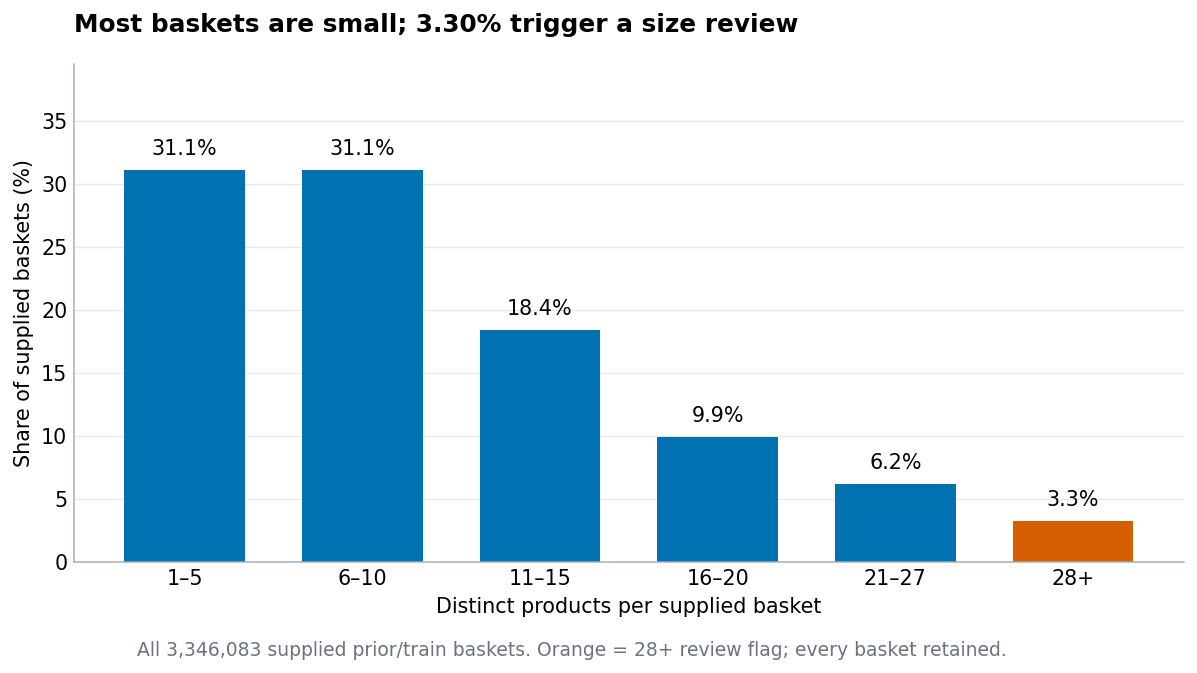

In [16]:
# Ordered categorical ranges: count orders in each range, not density or quantity.
basket_edges=[0,5,10,15,20,flag_from-1,np.inf]
basket_labels=['1–5','6–10','11–15','16–20',f'21–{flag_from-1}',f'{flag_from}+']
basket_distribution=pd.cut(clean_sizes,bins=basket_edges,labels=basket_labels).value_counts().reindex(basket_labels,fill_value=0)
basket_plot=pd.DataFrame({'Different products':basket_labels,'Orders':basket_distribution.values})
basket_plot['Share percent']=100*basket_plot.Orders/len(clean_sizes)
basket_plot.to_csv(AUDIT_DIR/'distribution_basket_size_story.csv',index=False)
fig,ax=plt.subplots(figsize=(9,4.8))
bars=ax.bar(basket_labels,basket_plot['Share percent'],color=[BLUE]*5+[ORANGE],width=.68)
ax.set_title(f'Most baskets are small; {flagged_share:.2f}% trigger a size review',loc='left',fontweight='bold',pad=17)
ax.set_xlabel('Distinct products per supplied basket')
ax.set_ylabel('Share of supplied baskets (%)')
ax.set_ylim(0,max(basket_plot['Share percent'])*1.27)
ax.bar_label(bars,labels=[f'{n:.1f}%' for n in basket_plot['Share percent']],padding=6,fontsize=11)
finish_axis(ax)
fig.text(.12,-.025,f'All {len(clean_sizes):,} supplied prior/train baskets. Orange = {flag_from}+ review flag; every basket retained.',fontsize=10,color=GRAY)
show_figure(fig,'02_basket_size_review.png')
CHART_DATA['basket_size']={'labels':basket_labels,'values':basket_plot.Orders.astype(int).tolist(),'share_percent':basket_plot['Share percent'].tolist(),'unit':'Supplied baskets','scope':f'All {len(clean_sizes):,} prior/train baskets; test baskets withheld','flag_from':flag_from,'upper_fence':upper_fence}
largest_group=str(basket_distribution.idxmax())


**What the audience should notice:** Basket size is right-skewed: many small baskets and a small tail of large ones. The orange bar identifies review cases using the stated rule. It does not label them incorrect.

**How we decide:** Review an actual large basket, confirm distinct purchase keys and complete cart positions, and keep it when no invalid record is found. Automatic deletion would discard real activity and bias later basket summaries downward.


**What would automatic deletion do?** The next table compares our actual retained data with a clearly marked hypothetical removal. It quantifies how a cleaning shortcut would change the dataset; we do not apply that removal. The actual large-basket example also shows another large order from the same customer for context.

In [17]:
largest_order_id=int(largest_examples.iloc[0].order_id)
large_rows=[]
for filename in ['order_products__prior.csv','order_products__train.csv']:
    for chunk in pd.read_csv(RAW_DIR/filename,chunksize=CHUNK_SIZE,dtype='int64'):
        selected=chunk.loc[chunk.order_id.eq(largest_order_id)]
        if len(selected): large_rows.append(selected)
large_basket=pd.concat(large_rows,ignore_index=True).sort_values('add_to_cart_order')
large_basket=large_basket.merge(products,on='product_id',validate='many_to_one').merge(depts,on='department_id',validate='many_to_one')
assert len(large_basket)==int(clean_sizes.max())
assert large_basket.product_id.is_unique
assert np.array_equal(np.sort(large_basket.add_to_cart_order),np.arange(1,len(large_basket)+1))
print(f'Actual large-basket example: order {largest_order_id:,} has {len(large_basket)} different products and positions 1–{len(large_basket)}.')
display(large_basket[['order_id','product_id','add_to_cart_order','product_name','department']].head(6))
large_basket.to_csv(AUDIT_DIR/'largest_basket_actual_products.csv',index=False)

# A sensitivity check explains why statistical flags must not trigger automatic deletion.
flagged_product_lines=int(outlier_review.distinct_products.sum())
all_product_lines=sum(source_counts.values())
original_mean=all_product_lines/len(clean_sizes)
mean_if_deleted=(all_product_lines-flagged_product_lines)/(len(clean_sizes)-flagged_count)
sensitivity=pd.DataFrame([
 {'Scenario':'Actual: keep all verified supplied baskets','Baskets':len(clean_sizes),'Product lines':all_product_lines,'Mean distinct products':round(original_mean,2)},
 {'Scenario':'Hypothetical: delete every IQR-flagged basket','Baskets':len(clean_sizes)-flagged_count,'Product lines':all_product_lines-flagged_product_lines,'Mean distinct products':round(mean_if_deleted,2)}])
display(sensitivity)
sensitivity.to_csv(AUDIT_DIR/'hypothetical_large_basket_deletion_effect.csv',index=False)
print(f'Flagged baskets account for {100*flagged_product_lines/all_product_lines:.2f}% of supplied product lines. This is a hypothetical deletion, not our cleaning result.')
user_id=int(largest_examples.iloc[0].user_id)
other_large_orders=outlier_review[outlier_review.user_id.eq(user_id)].sort_values('order_number')
print(f'Context: the same customer {user_id} has these IQR-flagged supplied baskets; this table shows review cases only.')
display(other_large_orders[['order_id','order_number','distinct_products']])


Actual large-basket example: order 1,564,244 has 145 different products and positions 1–145.
Flagged baskets account for 11.08% of supplied product lines. This is a hypothetical deletion, not our cleaning result.
Context: the same customer 22906 has these IQR-flagged supplied baskets; this table shows review cases only.


order_id,product_id,add_to_cart_order,product_name,department
1564244,46979,1,Asparagus,produce
1564244,15740,2,Pumpkin Fig Ancient Grain Granola,breakfast
1564244,47209,3,Organic Hass Avocado,produce
1564244,41363,4,Tofu Spring Roll,deli
1564244,27608,5,Organic Free Range Large Brown Grade A Eggs,dairy eggs
1564244,34270,6,"Cold-pressed, Deliciously Hydrating Watermelon Water",beverages


Scenario,Baskets,Product lines,Mean distinct products
Actual: keep all verified supplied baskets,3346083,33819106,10.11
Hypothetical: delete every IQR-flagged basket,3235803,30072043,9.29


order_id,order_number,distinct_products
61355,3,127
1564244,4,145
1509636,6,59
876932,7,46
1719410,9,78
404157,12,76
2244097,16,39
311364,17,51
2482710,19,33
1437167,20,28


## 6. Why does the day-gap distribution need context?

The dataset records gaps in whole days with a **maximum recorded value of 30**. A concentration at that boundary does not, by itself, prove invalid values. We retain the supplied values and describe the distribution as recorded; we do not assume that every 30 represents an exact uncapped waiting time.

The next chart includes **only known gaps from later orders**. It excludes first-order missing values. It uses integer day values, a zero count baseline, and a clear label for the maximum recorded value of 30.


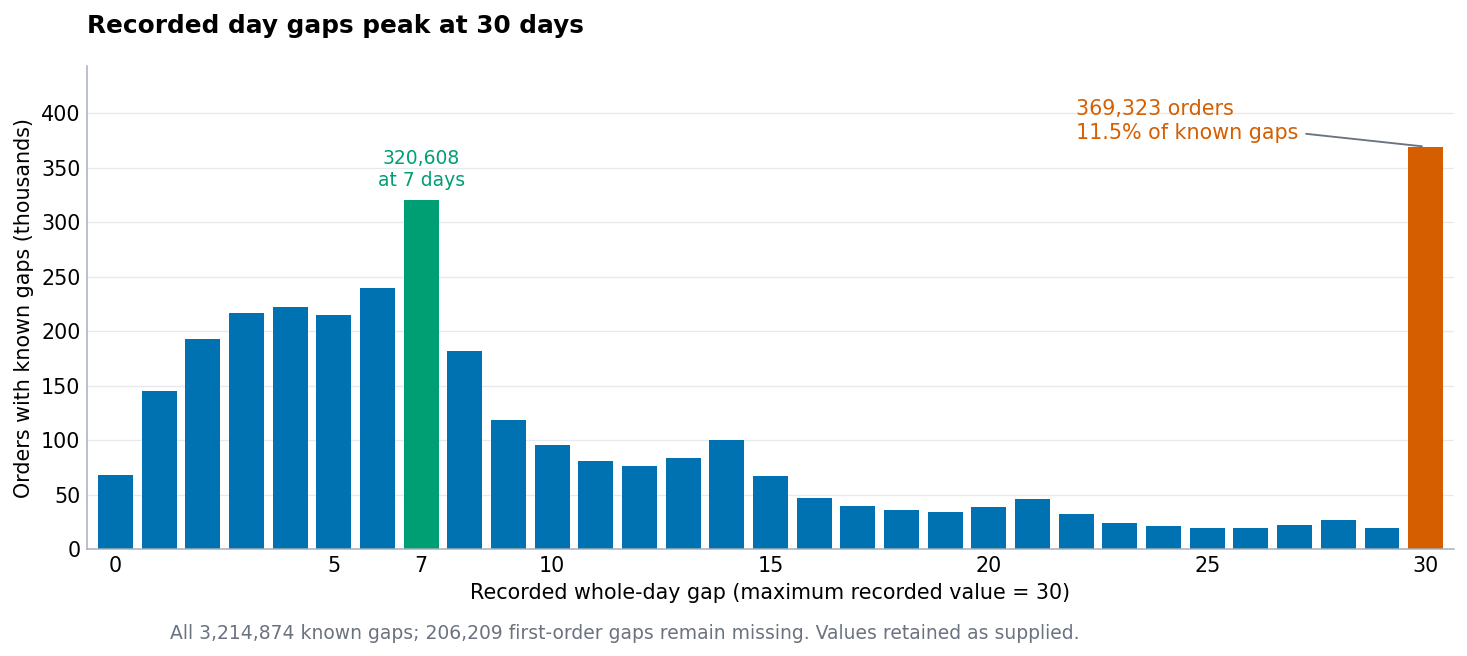

In [18]:
day_counts=known_gaps.astype(int).value_counts().reindex(range(31),fill_value=0)
day_table=pd.DataFrame({'Recorded gap days':range(31),'Orders':day_counts.values})
day_table.to_csv(AUDIT_DIR/'distribution_recorded_day_gap.csv',index=False)
cap_count=int(day_counts.loc[30]); cap_share=100*cap_count/len(known_gaps)
fig,ax=plt.subplots(figsize=(11,4.7))
colors=[BLUE]*31;colors[7]=TEAL;colors[30]=ORANGE
bars=ax.bar(range(31),day_counts/1000,color=colors,width=.8)
ax.set_title('Recorded day gaps peak at 30 days',loc='left',fontweight='bold',pad=18)
ax.set_xlabel('Recorded whole-day gap (maximum recorded value = 30)')
ax.set_ylabel('Orders with known gaps (thousands)')
ax.set_xticks([0,5,7,10,15,20,25,30],['0','5','7','10','15','20','25','30'])
ax.set_xlim(-.65,30.65);ax.set_ylim(0,(day_counts.max()/1000)*1.2)
ax.annotate(f'{cap_count:,} orders\n{cap_share:.1f}% of known gaps',xy=(30,cap_count/1000),xytext=(22,cap_count/1000*1.02),arrowprops={'arrowstyle':'-','color':GRAY},color=ORANGE,fontsize=11,ha='left')
ax.text(7,day_counts.loc[7]/1000+13,f'{day_counts.loc[7]:,}\nat 7 days',ha='center',fontsize=10,color=TEAL)
finish_axis(ax)
fig.text(.12,-.02,f'All {len(known_gaps):,} known gaps; {int(missing.sum()):,} first-order gaps remain missing. Values retained as supplied.',fontsize=10,color=GRAY)
show_figure(fig,'03_recorded_day_gaps.png')
CHART_DATA['day_gap']={'labels':[str(i) for i in range(31)],'values':day_counts.astype(int).tolist(),'unit':'Later orders with known recorded gaps','scope':f'All {len(known_gaps):,} known gaps','recorded_30_count':cap_count,'recorded_30_share_percent':cap_share,'zero_count':zero_count}


**Why useful later:** Timing summaries should distinguish missing first-order gaps, actual 0-day gaps and the maximum recorded gap of 30. We can describe the recorded distribution; the data cannot tell us a confirmed uncapped waiting time.


## 7. When are orders placed?

A single hourly chart describes customer activity in the full Orders table. It does not measure revenue, price, profit or purchased quantity. We highlight the peak directly, with the remaining hours shown consistently.


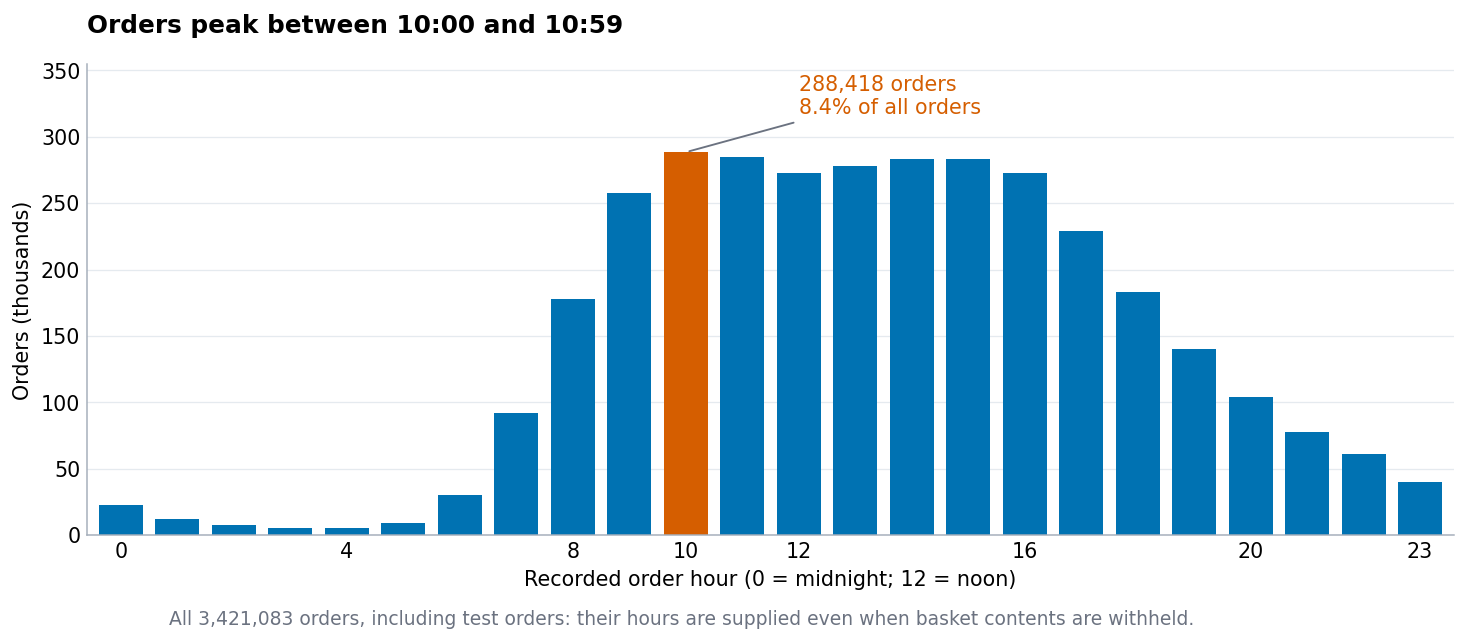

In [19]:
hours=np.arange(24)
hour_counts=orders.order_hour_of_day.value_counts().reindex(hours,fill_value=0)
peak_hour=int(hour_counts.idxmax());peak_hour_count=int(hour_counts.max())
pd.DataFrame({'Hour':hours,'Orders':hour_counts.values}).to_csv(AUDIT_DIR/'distribution_orders_by_hour_story.csv',index=False)
fig,ax=plt.subplots(figsize=(11,4.6))
colors=[ORANGE if h==peak_hour else BLUE for h in hours]
ax.bar(hours,hour_counts/1000,color=colors,width=.78)
ax.set_title(f'Orders peak between {peak_hour}:00 and {peak_hour}:59',loc='left',fontweight='bold',pad=17)
ax.set_xlabel('Recorded order hour (0 = midnight; 12 = noon)')
ax.set_ylabel('Orders (thousands)')
ax.set_xticks([0,4,8,10,12,16,20,23]);ax.set_xlim(-.6,23.6)
ax.set_ylim(0,hour_counts.max()/1000*1.23)
ax.annotate(f'{peak_hour_count:,} orders\n{100*peak_hour_count/len(orders):.1f}% of all orders',xy=(peak_hour,peak_hour_count/1000),xytext=(peak_hour+2,peak_hour_count/1000*1.1),arrowprops={'arrowstyle':'-','color':GRAY},fontsize=11,color=ORANGE)
finish_axis(ax)
fig.text(.12,-.02,f'All {len(orders):,} orders, including test orders: their hours are supplied even when basket contents are withheld.',fontsize=10,color=GRAY)
show_figure(fig,'04_orders_by_hour.png')
CHART_DATA['order_hour']={'labels':hours.astype(str).tolist(),'values':hour_counts.astype(int).tolist(),'unit':'Orders','scope':f'All {len(orders):,} supplied orders','peak_hour':peak_hour,'peak_orders':peak_hour_count}


**Why useful later:** Verified hour codes support a reliable SQL `GROUP BY order_hour_of_day`. The result shows when activity is concentrated in these records. High order counts alone do not prove higher prices or profit.


## 8. What changed, what stayed and why?

The summary separates actual corrections from justified retention decisions. Preserving a meaningful NULL, a distinct ID or a verified large basket is part of data cleaning.


In [20]:
before_after = pd.DataFrame([
    {'Cleaning topic':'Product-name spacing','Before':'424 names with spacing issues','After':'0 names with those spacing issues','What we did':'Trim ends, replace no-break spaces, use one space','Useful later':'Consistent text search and readable labels'},
    {'Cleaning topic':'First-order missing gaps','Before':f'{int(interval_blank.sum()):,} empty fields','After':f'{int(missing.sum()):,} meaningful missing values','What we did':'Keep missing; import as SQL NULL','Useful later':'Avoid false zero-day gaps and biased averages'},
    {'Cleaning topic':'Unexpected missing values','Before':'0 in the other supplied columns','After':'0','What we did':'Check all columns; no fill needed','Useful later':'Required IDs and flags are available'},
    {'Cleaning topic':'Duplicate rows and keys','Before':'0 accidental duplicates','After':'0','What we did':'Check complete files and their union; retain rows','Useful later':'Purchase counts are not inflated'},
    {'Cleaning topic':'Matching names, different IDs','Before':'0 matching-name groups','After':f'{collision_groups} groups after spacing cleanup','What we did':'Retain all IDs; save a review list','Useful later':'Do not delete valid catalog entries'},
    {'Cleaning topic':'Invalid value ranges','Before':'0 invalid checked values','After':'0','What we did':'Validate hours, gaps, flags, and cart positions','Useful later':'Trustworthy grouping and calculations'},
    {'Cleaning topic':'Valid zeros and recorded maximum gaps','Before':'Valid 0 and 30 values','After':'Same values retained','What we did':'Interpret values using column meaning','Useful later':'Preserve real timing and midnight orders'},
    {'Cleaning topic':'Total source records','Before':f'{len(orders):,} orders; {sum(source_counts.values()):,} purchases','After':f'{len(orders):,} orders; {sum(source_counts.values()):,} purchases','What we did':'No records removed','Useful later':'Team works with the complete supplied dataset'},
    {'Cleaning topic':'Statistically large baskets','Before':f'{flagged_count:,} baskets at {flag_from}+ distinct products','After':'All retained; review flags exported','What we did':'Inspect exact records and verify keys/positions','Useful later':'Avoid deleting valid tail behaviour and biasing basket summaries'}])
before_after.to_csv(AUDIT_DIR/'before_after_transformations.csv',index=False)
before_after.to_csv(AUDIT_DIR/'cleaning_decisions.csv',index=False)
display(before_after)

Cleaning topic,Before,After,What we did,Useful later
Product-name spacing,424 names with spacing issues,0 names with those spacing issues,"Trim ends, replace no-break spaces, use one space",Consistent text search and readable labels
First-order missing gaps,"206,209 empty fields","206,209 meaningful missing values",Keep missing; import as SQL NULL,Avoid false zero-day gaps and biased averages
Unexpected missing values,0 in the other supplied columns,0,Check all columns; no fill needed,Required IDs and flags are available
Duplicate rows and keys,0 accidental duplicates,0,Check complete files and their union; retain rows,Purchase counts are not inflated
"Matching names, different IDs",0 matching-name groups,37 groups after spacing cleanup,Retain all IDs; save a review list,Do not delete valid catalog entries
Invalid value ranges,0 invalid checked values,0,"Validate hours, gaps, flags, and cart positions",Trustworthy grouping and calculations
Valid zeros and recorded maximum gaps,Valid 0 and 30 values,Same values retained,Interpret values using column meaning,Preserve real timing and midnight orders
Total source records,"3,421,083 orders; 33,819,106 purchases","3,421,083 orders; 33,819,106 purchases",No records removed,Team works with the complete supplied dataset
Statistically large baskets,"110,280 baskets at 28+ distinct products",All retained; review flags exported,Inspect exact records and verify keys/positions,Avoid deleting valid tail behaviour and biasing basket summaries


### Export the cleaned data and verify it

Write the four catalog/order files and combine the two validated purchase files
into `order_products.csv` for the team. **Combining files is handoff preparation,
not a cleaning correction.** All purchase values and records are preserved.

Member 2 uses the cleaned catalog and its aisle–department mapping for the
database design. Member 3 imports the CSVs, converts empty day-gap fields to
SQL NULL, and verifies the database. Your teammates can find import notes in
the ZIP's README.

The exported tables are staging tables. Combining prior and train is file consolidation, not normalization. Keep `eval_set` so withheld test baskets can be identified. The outlier review flag is an audit report, not a row-deletion instruction.

In [21]:
audit_checks = pd.DataFrame(checks)
if audit_checks.status.ne('PASS').any():
    display(audit_checks[audit_checks.status.ne('PASS')])
    raise ValueError('Review these findings before exporting the team data.')
for filename,frame in clean.items():
    frame.to_csv(TABLE_DIR/filename,index=False,encoding='utf-8',na_rep='')
merged_path = TABLE_DIR/'order_products.csv'
temporary = merged_path.with_suffix('.csv.tmp')
with temporary.open('wb') as output:
    for i,filename in enumerate(['order_products__prior.csv','order_products__train.csv']):
        with (RAW_DIR/filename).open('rb') as source:
            header = source.readline()
            if i == 0:
                output.write(header)
            shutil.copyfileobj(source,output,length=4*1024*1024)
        with (RAW_DIR/filename).open('rb') as source:
            source.seek(-1,2)
            if source.read(1) != b'\n':
                output.write(b'\n')
temporary.replace(merged_path)
output_counts = {filename:len(frame) for filename,frame in clean.items()}
output_counts['order_products.csv'] = sum(source_counts.values())
print('Five cleaned CSVs exported. Verifying the actual saved files next.')

Five cleaned CSVs exported. Verifying the actual saved files next.


In [22]:
reloaded = {}
for filename, expected in clean.items():
    numeric_types = {c:str(expected[c].dtype) for c in expected.columns if c not in TEXT}
    loaded = pd.read_csv(TABLE_DIR/filename,keep_default_na=False,
                         na_values={'days_since_prior_order':['']},dtype=numeric_types)
    reloaded[filename] = loaded
    for column in expected:
        check('Export '+filename+'.'+column+': changed/lost values',0 if loaded[column].equals(expected[column]) else 1,
              'Saved data must match cleaned values and missingness.')
clean_basket_counts = np.zeros_like(basket_counts)
merged_rows = 0
for chunk in pd.read_csv(merged_path,chunksize=CHUNK_SIZE,
                         dtype={'order_id':'uint32','product_id':'uint32','add_to_cart_order':'uint16','reordered':'uint8'}):
    merged_rows += len(chunk)
    clean_basket_counts += np.bincount(chunk.order_id.to_numpy(dtype=np.int64),minlength=len(basket_counts)).astype(np.int32)
check('Export merged purchase row count',abs(merged_rows-sum(source_counts.values())),'Keep every purchase record.')
check('Export changed basket sizes',int(np.count_nonzero(clean_basket_counts!=basket_counts)),'Every supplied basket size must remain unchanged.')
expected_digest = hashlib.sha256()
for i,filename in enumerate(['order_products__prior.csv','order_products__train.csv']):
    with (RAW_DIR/filename).open('rb') as source:
        header=source.readline()
        if i==0:
            expected_digest.update(header)
        for block in iter(lambda:source.read(4*1024*1024),b''):
            expected_digest.update(block)
    with (RAW_DIR/filename).open('rb') as source:
        source.seek(-1,2)
        if source.read(1)!=b'\n':
            expected_digest.update(b'\n')
check('Export merged purchase byte-preservation check',0 if sha256(merged_path)==expected_digest.hexdigest() else 1,
      'Saved purchases equal the original values, with one header.')
for row in manifest.itertuples(index=False):
    check('Input unchanged: '+row.file,0 if sha256(RAW_DIR/row.file)==row.sha256 else 1,'Inputs used by this run must stay unchanged.')
audit_checks = pd.DataFrame(checks)
assert audit_checks.status.eq('PASS').all(), 'Investigate failed checks before sharing.'
audit_checks.to_csv(AUDIT_DIR/'validation_checks.csv',index=False)
output_manifest = pd.DataFrame([{'file':filename,'rows':rows,'bytes':(TABLE_DIR/filename).stat().st_size,
                                'sha256':sha256(TABLE_DIR/filename)} for filename,rows in output_counts.items()])
output_manifest.to_csv(AUDIT_DIR/'cleaned_file_manifest.csv',index=False)
contract = {filename:{col:str(dtype) for col,dtype in frame.dtypes.items()} for filename,frame in clean.items()}
contract['order_products.csv']={'order_id':'uint32','product_id':'uint32','add_to_cart_order':'uint16','reordered':'uint8'}
(AUDIT_DIR/'processing_dtype_contract.json').write_text(json.dumps(contract,indent=2))
pd.DataFrame([{'file':filename,'column':col,'before_dtype':str(raw[filename][col].dtype),'after_dtype':str(frame[col].dtype)}
              for filename,frame in clean.items() for col in frame]).to_csv(AUDIT_DIR/'dtype_before_after.csv',index=False)
display(output_manifest[['file','rows']].rename(columns={'file':'Cleaned file','rows':'Rows retained'}))
print('Passed checks:',len(audit_checks),'| Records deleted: 0')

Passed checks: 86 | Records deleted: 0


Cleaned file,Rows retained
products.csv,49688
aisles.csv,134
departments.csv,21
orders.csv,3421083
order_products.csv,33819106


In [23]:
summary={'input_mode':ACTIVE_INPUT_MODE,'input_provenance':INPUT_PROVENANCE,
 'source_rows':{row['file']:int(row['rows']) for row in inventory},'cleaned_rows':output_counts,
 'users':int(orders.user_id.nunique()),'product_labels_standardized':format_before,
 'expected_missing_intervals_retained':int(missing.sum()),'matching_name_groups_retained':collision_groups,
 'passed_checks':len(audit_checks),'rows_removed':0,'observed_baskets':len(clean_sizes),
 'median_basket_distinct_products':median_basket,'largest_basket_distinct_products':int(clean_sizes.max()),
 'withheld_test_orders':int(orders.eval_set.eq('test').sum()),'peak_order_hour':peak_hour,'peak_hour_orders':peak_hour_count,
 'most_common_basket_range':largest_group,'basket_q1':float(q1),'basket_q3':float(q3),'basket_iqr':float(iqr),
 'basket_upper_fence':upper_fence,'basket_flag_from':flag_from,'flagged_large_baskets':flagged_count,'flagged_share_percent':flagged_share,
 'largest_order_id':largest_order_id,'known_gap_count':len(known_gaps),'zero_day_gap_count':zero_count,
 'recorded_30_count':cap_count,'recorded_30_share_percent':cap_share,'known_recorded_gap_mean':known_mean,'zero_filled_gap_mean':zero_filled_mean,
 'versions':{'pandas':pd.__version__,'numpy':np.__version__,'matplotlib':matplotlib.__version__}}
(AUDIT_DIR/'run_summary.json').write_text(json.dumps(summary,indent=2))
(AUDIT_DIR/'story_chart_data.json').write_text(json.dumps(CHART_DATA,indent=2))
print('Story evidence and editable-chart data saved. Records removed: 0.')
display(pd.DataFrame({'What the team receives':['Five complete CSV tables','Full-file validation and export hashes','Actual name-change and NULL examples','Large-basket flags and actual example products','Four purposeful charts and their underlying data'],
 'Why':['Continue database/import/query work','Confirm keys, references, ranges and preserved values','Explain the cleaning decisions with real records','Review unusual values without losing valid data','Reuse clear evidence in the presentation']}))


Story evidence and editable-chart data saved. Records removed: 0.


What the team receives,Why
Five complete CSV tables,Continue database/import/query work
Full-file validation and export hashes,"Confirm keys, references, ranges and preserved values"
Actual name-change and NULL examples,Explain the cleaning decisions with real records
Large-basket flags and actual example products,Review unusual values without losing valid data
Four purposeful charts and their underlying data,Reuse clear evidence in the presentation


## Issues, solutions and processing challenges

| Requirement or issue | Our solution | Why it helps the team |
| --- | --- | --- |
| 33.8 million purchase lines exceed a convenient one-table view | Read 500,000 rows at a time; exact full-file keys and union checks still cover every record | Manage input memory while preserving complete validation |
| Invisible/repeated spaces in labels | Standardize spaces and keep an actual before/after audit log | Consistent text lookup and readable outputs |
| First-order gap is blank but zero is a real value | Keep missing and import as SQL NULL; retain recorded zero-day gaps | Avoid biased timing averages |
| Equal cleaned names belong to different IDs | Log matching-name groups; keep product IDs and join on IDs | Preserve catalog identity and valid purchases |
| Some baskets are statistically large | Apply the stated IQR review rule, inspect real cart rows and verify keys/positions | Review the tail without deleting real activity |
| Test orders lack supplied basket contents | Keep eval_set and exclude only withheld contents from basket-size denominators | Avoid counting unknown baskets as zero |
| Saved CSVs might differ from in-memory results | Re-read exported tables, compare values/counts and record hashes | Give teammates a verifiable handoff |

These are requirements handled by the workflow, not claims of crashes or corrupted source files.


## Tell the audience the story

1. **Why:** Orders, products and purchase lines need to connect correctly for reliable SQL analysis.
2. **What:** Fix the 424 genuine spacing issues; show one actual product example.
3. **When to keep:** A first-order gap should remain NULL. The same label across different IDs does not prove duplicate products.
4. **How to review:** Flag large baskets with a stated statistical rule, inspect actual cart rows and verify their keys and sequence. Retain verified baskets.
5. **What we learn:** Small baskets are common, a small size tail needs review, maximum recorded gaps need context, and hourly counts describe activity.
6. **What leaves this notebook:** Full cleaned staging CSVs, an audit trail and understandable figures. No unjustified deletion and no repeated unchanged before/after charts.

The charts use a colourblind-friendly blue, orange and teal palette. Colour communicates a specific role, highlighted values have direct labels, bar axes start at zero, units and denominators are explicit, and categorical ranges are ordered. No 3-D effects, dual axes or rainbow palettes are needed.


In [24]:
readme=f"""# Instacart Member 1 — cleaned-data story

## Reproducibility and provenance
Mode used for this run: {ACTIVE_INPUT_MODE}
{INPUT_PROVENANCE}
Original mode is preferred for a new raw-file cleaning run. Prepared mode verifies the previous table hashes, restores only logged before-label strings for a transparent replay, and rechecks complete supplied records. Its replay inputs are not original source byte files.

## Complete team tables
- tables/orders.csv: {len(orders):,} rows
- tables/products.csv: {len(products):,} rows
- tables/aisles.csv: {len(aisles):,} rows
- tables/departments.csv: {len(depts):,} rows
- tables/order_products.csv: {sum(source_counts.values()):,} rows

Spacing standardized in {format_before} product names. Rows removed: zero.
First-order previous-order gaps remain empty in CSV: import them as SQL NULL.
Keep eval_set. Test contents are withheld; {summary['withheld_test_orders']:,} test orders are not empty baskets.
Combining prior/train is consolidation, not a cleaning correction or normalization.
Products are staging records; use audit/aisle_department_mapping.csv for the proposed catalog 3NF design.
Names are not unique keys; {collision_groups} cleaned matching-name groups retain separate product IDs.

## Unusual values
The basket review fence is {upper_fence:g}, so {flag_from}+ distinct products are flagged.
{flagged_count:,} of {len(clean_sizes):,} supplied baskets ({flagged_share:.2f}%) are flagged, and all are retained.
The largest basket has {int(clean_sizes.max())} distinct products. Actual rows are in audit/largest_basket_actual_products.csv.
These data do not contain quantities or prices. The maximum recorded gap is 30; do not claim it is every true uncapped waiting time.

## Reports and figures
Four purposeful PNG figures in figures/; unchanged before/after distributions were removed.
Chart values: audit/story_chart_data.json. Full executed checks: audit/validation_checks.csv.
Audit examples show label corrections, NULL decisions, exact basket review cases and table hashes.

## Run again
Open Instacart_Data_Cleaning_Story.ipynb. Provide six original CSVs in raw_data/ or provide Instacart_Cleaned_Data.zip and select prepared mode. Run all cells.
Dependencies: pandas, numpy, matplotlib. Dataset: https://www.kaggle.com/datasets/psparks/instacart-market-basket-analysis
"""
(OUT_DIR/'README.md').write_text(readme,encoding='utf-8')
(OUT_DIR/'requirements.txt').write_text(f'pandas=={pd.__version__}\nnumpy=={np.__version__}\nmatplotlib=={matplotlib.__version__}\n')
archive=Path('Instacart_Cleaned_Data_Story.zip')
# Preserve a prepared ZIP if it was the input to this run.
if ACTIVE_INPUT_MODE=='prepared' and archive.resolve()==PREPARED_ZIP.resolve():
    archive=Path('Instacart_Cleaned_Data_Story_Rerun.zip')
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED,compresslevel=6) as z:
    for path in sorted(OUT_DIR.rglob('*')):
        if path.is_file() and 'prepared_audit_replay_inputs' not in path.parts:
            z.write(path,path)
print('Cleaned ZIP ready:',archive.resolve())
print('Size:',round(archive.stat().st_size/1e6,1),'MB')
print('Full run elapsed:',round((time.monotonic()-START)/60,1),'minutes')
try:
    from google.colab import files
    from IPython.display import HTML
    display(HTML('<b>Colab:</b> run the next cell to download the complete cleaned ZIP.'))
except ImportError:
    try:
        from IPython.display import FileLink
        display(FileLink(str(archive)))
    except ImportError:
        print('Jupyter: download the ZIP from the file browser.')


Cleaned ZIP ready: /workspace/scratch/6212dd03a2d1/tmp/story_notebook/run/Instacart_Cleaned_Data_Story.zip
Size: 206.8 MB
Full run elapsed: 2.1 minutes
Jupyter: download the ZIP from the file browser.


### Download the cleaned data
In **Colab**, run the cell below to download the ZIP. In Jupyter, use the link above or the file browser. The ZIP contains the full CSV tables, not just plotted samples. Each member can use these files for their part of the project.

In [25]:
try:
    from google.colab import files
    files.download(str(archive))
except ImportError:
    print('Use the Jupyter download link above:',archive.resolve())


Use the Jupyter download link above: /workspace/scratch/6212dd03a2d1/tmp/story_notebook/run/Instacart_Cleaned_Data_Story.zip
